In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from dataset import DiffusionDataset, get_dataloader, sin_1d
from utils.diffusion import Diffusion, cosine_schedule
from models.mlp import ScoreModel
from models.train import train_score_mlp

# Generate data

In [15]:
dataset = DiffusionDataset(dataset_name='sin_1d', n_samples=5000, seed=42, x_normalise=True, y_normalise=True)
train_loader, test_loader, val_loader = get_dataloader(dataset, batch_size=32, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)
batch = next(iter(train_loader))
batch['X'].shape
batch['y'].shape

torch.Size([32, 1])

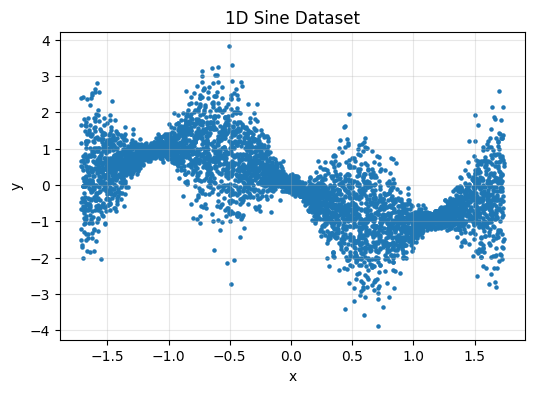

In [16]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
plt.scatter(dataset.X, dataset.y, s=5)

# Diffusion process

torch.Size([1001])
torch.Size([1001])
torch.Size([1001])
tensor(1.) tensor(0.0010)
tensor(0.) tensor(0.9990)
tensor(1.) tensor(1.9110e-15)


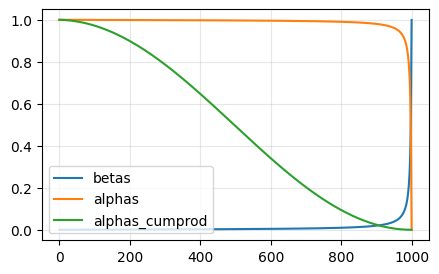

In [7]:
# check the schedules
betas, alphas, alphas_cumprod = cosine_schedule(1000)
print(betas.shape)
print(alphas.shape)
print(alphas_cumprod.shape)

print(alphas[0], alphas[-1])
print(betas[0], betas[-1])
print(alphas_cumprod[0], alphas_cumprod[-1])

plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
plt.plot(betas, label='betas')
plt.plot(alphas, label='alphas')
plt.plot(alphas_cumprod, label='alphas_cumprod')
plt.legend(loc='lower left')

torch.Size([1000])
torch.Size([1000])
torch.Size([1000])


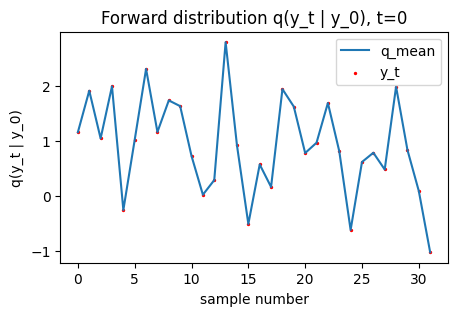

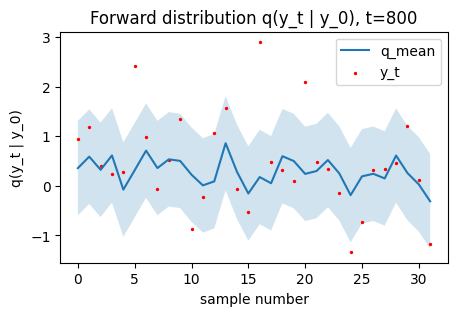

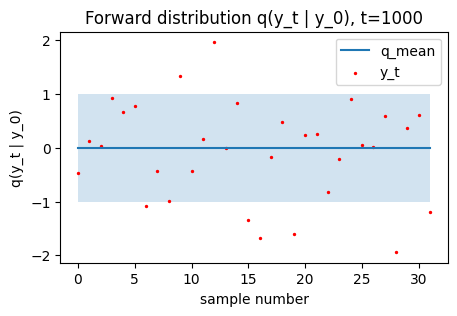

torch.Size([32])
torch.Size([32])


In [8]:
d = Diffusion(T=1000)
print(d.posterior_variance.shape)
print(d.posterior_mean_coef1.shape)
print(d.posterior_mean_coef2.shape)

y0 = batch['y']

plt.figure(figsize=(5, 3))
t = 0
q_mean, q_var = d.forward_q(y0, t)
# sample y_t from q(y_t | y_0)
noise = torch.randn_like(y0)
y_t = d.q_sample(y0, t, noise)
plt.title(f'Forward distribution q(y_t | y_0), t={t}')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_0)')
plt.plot(q_mean, label='q_mean')
# fill between standard deviation
plt.fill_between(range(len(q_mean)), q_mean - q_var**0.5, q_mean + q_var**0.5, alpha=0.2)
plt.scatter(range(len(y_t)), y_t, s=2, c='r', label='y_t')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
t = 800
q_mean, q_var = d.forward_q(y0, t)
# sample y_t from q(y_t | y_0)
noise = torch.randn_like(y0)
y_t = d.q_sample(y0, t, noise)
plt.title(f'Forward distribution q(y_t | y_0), t={t}')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_0)')
plt.plot(q_mean, label='q_mean')
# fill between standard deviation
plt.fill_between(range(len(q_mean)), q_mean - q_var**0.5, q_mean + q_var**0.5, alpha=0.2)
plt.scatter(range(len(y_t)), y_t, s=2, c='r', label='y_t')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
t = 1000
q_mean, q_var = d.forward_q(y0, t)
# sample y_t from q(y_t | y_0)
noise = torch.randn_like(y0)
y_t = d.q_sample(y0, t, noise)
plt.title(f'Forward distribution q(y_t | y_0), t={t}')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_0)')
plt.plot(q_mean, label='q_mean')
# fill between standard deviation
plt.fill_between(range(len(q_mean)), q_mean - q_var**0.5, q_mean + q_var**0.5, alpha=0.2)
plt.scatter(range(len(y_t)), y_t, s=2, c='r', label='y_t')
plt.legend()
plt.show()

print(q_mean.shape)
print(q_var.shape)


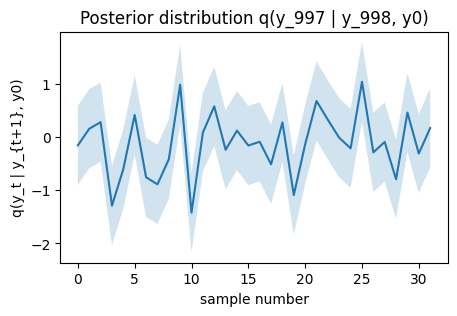

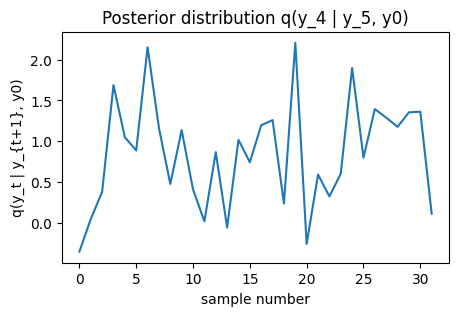

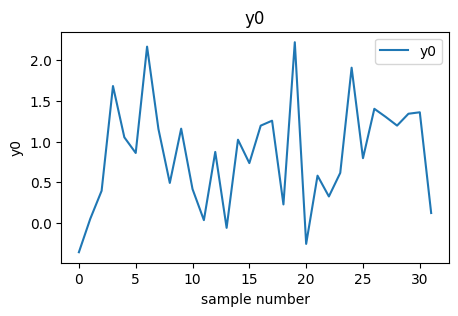

In [11]:
# sample y_T from q(y_T | y_0)
t = 998
q_mean, q_var = d.forward_q(y0, t) # get the forward distribution q(y_t | y_0)
y_t = q_mean + torch.randn_like(q_mean) * torch.sqrt(q_var) # sample y_T from q(y_t | y_0)
q_posterior_mean, q_posterior_var = d.reverse_q(y0, y_t, t-1)
plt.figure(figsize=(5, 3))
plt.title(f'Posterior distribution q(y_{t-1} | y_{t}, y0)')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_{t+1}, y0)')
plt.plot(q_posterior_mean, label='q_posterior_mean')
# fill between standard deviation
plt.fill_between(range(len(q_posterior_mean)), q_posterior_mean - q_posterior_var**0.5, q_posterior_mean + q_posterior_var**0.5, alpha=0.2)

t = 5
q_mean, q_var = d.forward_q(y0, t) # get the forward distribution q(y_t | y_0)
y_t = q_mean + torch.randn_like(q_mean) * torch.sqrt(q_var) # sample y_T from q(y_t | y_0)
q_posterior_mean, q_posterior_var = d.reverse_q(y0, y_t, t-1)
plt.figure(figsize=(5, 3))
plt.title(f'Posterior distribution q(y_{t-1} | y_{t}, y0)')
plt.xlabel('sample number')
plt.ylabel('q(y_t | y_{t+1}, y0)')
plt.plot(q_posterior_mean, label='q_posterior_mean')
# fill between standard deviation
plt.fill_between(range(len(q_posterior_mean)), q_posterior_mean - q_posterior_var**0.5, q_posterior_mean + q_posterior_var**0.5, alpha=0.2)

# plot the y0
plt.figure(figsize=(5, 3))
plt.title('y0')
plt.xlabel('sample number')
plt.ylabel('y0')
plt.plot(y0, label='y0')
plt.legend()
plt.show()


# Training

In [17]:
model, train_loss, val_loss = train_score_mlp(train_loader, val_loader, hidden_dims=[64, 64, 128], time_embed_dim=64, epoch_update=10, num_epochs=200, time_steps=1000, learning_rate=1e-4, device_type='cpu', save_path=None)

Epoch 0/200, Train Loss: 0.5298, Val Loss: 0.4272
Epoch 10/200, Train Loss: 0.3809, Val Loss: 0.3696
Epoch 20/200, Train Loss: 0.3566, Val Loss: 0.3609
Epoch 30/200, Train Loss: 0.3527, Val Loss: 0.3474
Epoch 40/200, Train Loss: 0.3443, Val Loss: 0.3092
Epoch 50/200, Train Loss: 0.3513, Val Loss: 0.2935
Epoch 60/200, Train Loss: 0.3505, Val Loss: 0.3703
Epoch 70/200, Train Loss: 0.3451, Val Loss: 0.2559
Epoch 80/200, Train Loss: 0.3371, Val Loss: 0.3446
Epoch 90/200, Train Loss: 0.3276, Val Loss: 0.3334
Epoch 100/200, Train Loss: 0.3362, Val Loss: 0.3019
Epoch 110/200, Train Loss: 0.3459, Val Loss: 0.3362
Epoch 120/200, Train Loss: 0.3410, Val Loss: 0.3825
Epoch 130/200, Train Loss: 0.3477, Val Loss: 0.3039
Epoch 140/200, Train Loss: 0.3363, Val Loss: 0.3630
Epoch 150/200, Train Loss: 0.3472, Val Loss: 0.4212
Epoch 160/200, Train Loss: 0.3481, Val Loss: 0.3901
Epoch 170/200, Train Loss: 0.3392, Val Loss: 0.3469
Epoch 180/200, Train Loss: 0.3273, Val Loss: 0.3094
Epoch 190/200, Train Lo

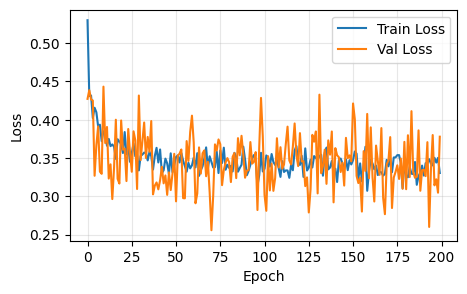

In [18]:
plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.show()

In [19]:
def sample_from_model(model, location, num_samples, device):
    y_t = torch.randn(num_samples).to(device)
    x = torch.ones_like(y_t) * location
    diffusion = Diffusion(T=1000, device=device)
    
    for t in range(999, -1, -1):
        t_tensor = torch.ones_like(y_t) * (t+1)
        score = model(x, y_t, t_tensor)
        y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score)
        y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])
        y_t = torch.clamp(y_t, min=-5.0, max=5.0) # y_t is still normalised
    return y_t

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_locations = []
predictions = []
true_values = []
T=1000
diffusion = Diffusion(T=1000, device=device)
with tqdm(total=len(test_loader)) as pbar:
    for batch in test_loader:
        X = batch['X'].to(device)[:,0]
        y_0 = batch['y'].to(device)[:,0]
        y_t = torch.randn_like(y_0, device=device)
        
        for t in range(T-1, -1, -1):
            t_tensor = torch.ones_like(y_t) * (t+1)
            score = model(X, y_t, t_tensor)
            y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score)
            y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])
            y_t = torch.clamp(y_t, min=-5.0, max=5.0)
        predictions.append(y_t.detach().cpu().numpy())
        true_values.append(y_0.detach().cpu().numpy())
        test_locations.append(X.detach().cpu().numpy())
        pbar.update(1)

test_locations = np.concatenate(test_locations, axis=0)
predictions = np.concatenate(predictions, axis=0)
true_values = np.concatenate(true_values, axis=0)

100%|██████████| 16/16 [00:06<00:00,  2.55it/s]


In [21]:
x_scaler, y_scaler = dataset.x_scaler, dataset.y_scaler
def f(x):
    return 1 + np.sin(2 * np.pi * x)
def std(x):
    return 0.1 + 0.1 * np.sin(2 * np.pi * x)


In [33]:
num_locations = 200
num_samples = 100
mse_x = np.linspace(0, 1, num_locations).reshape(-1, 1)
mse_y = f(mse_x)
mse_x = torch.tensor(x_scaler.transform(mse_x), dtype=torch.float32).flatten()
mse_y = torch.tensor(y_scaler.transform(mse_y), dtype=torch.float32).flatten()

results = np.zeros((num_locations,num_samples))
device = torch.device('cpu')

model.eval()
with tqdm(range(len(mse_x))) as pbar:
    for i, location in enumerate(mse_x):
        results[i] = sample_from_model(model, location, num_samples, device).detach().numpy()
        pbar.update(1)

results.shape

100%|██████████| 200/200 [02:22<00:00,  1.40it/s]


(200, 100)

In [38]:
results_mean

array([ 2.24771215e-01,  2.39130041e-01,  2.74153084e-01,  1.78739548e-01,
        3.07961230e-01,  4.01292938e-01,  3.61407878e-01,  3.76877984e-01,
        4.79578578e-01,  3.50175729e-01,  3.17637783e-01,  4.26266002e-01,
        4.94013276e-01,  4.75144103e-01,  4.88586952e-01,  5.62812839e-01,
        5.39594898e-01,  5.82384861e-01,  6.02868366e-01,  6.38564677e-01,
        7.23116160e-01,  7.36299777e-01,  7.53625292e-01,  8.06084080e-01,
        8.16885990e-01,  8.14831557e-01,  8.81235700e-01,  8.54006520e-01,
        9.16749431e-01,  8.98202656e-01,  9.40304149e-01,  9.30264335e-01,
        9.58885375e-01,  9.66589423e-01,  9.86676507e-01,  9.83555233e-01,
        1.02233816e+00,  1.03787553e+00,  1.02910830e+00,  1.04847213e+00,
        1.07649017e+00,  1.04121572e+00,  1.06883173e+00,  1.08564100e+00,
        1.20369021e+00,  1.17569340e+00,  1.18602339e+00,  1.13433709e+00,
        1.18263058e+00,  1.06687258e+00,  1.11357482e+00,  1.12475966e+00,
        1.05431115e+00,  

In [41]:
from sklearn.metrics import mean_squared_error
results_mean = np.mean(results, axis=1)
results_std = np.std(results, axis=1)
results_mean = torch.tensor(results_mean)
results_std = torch.tensor(results_std)
rmse = mean_squared_error(y_pred=results_mean, y_true=mse_y)
rmse = np.sqrt(rmse)
print(f"RMSE: {rmse}")

# calculate negative log likelihood
def gaussian_nll(y_true, mu, sigma):
    return 0.5 * torch.log(2 * torch.pi * sigma**2) + (y_true - mu)**2 / (2 * sigma**2)

nll = 0
for i in range(len(results_mean)):
    nll += gaussian_nll(mse_y[i], results_mean[i], results_std[i])
nll = nll / len(results_mean)
print(f"NLL: {nll}")

RMSE: 0.1431694773292325
NLL: 0.21644230902506145


In [42]:
def f(x):
    return 1 + np.sin(2 * np.pi * x)
def std(x):
    return 0.5 + 0.4 * np.cos(6 * np.pi * x)

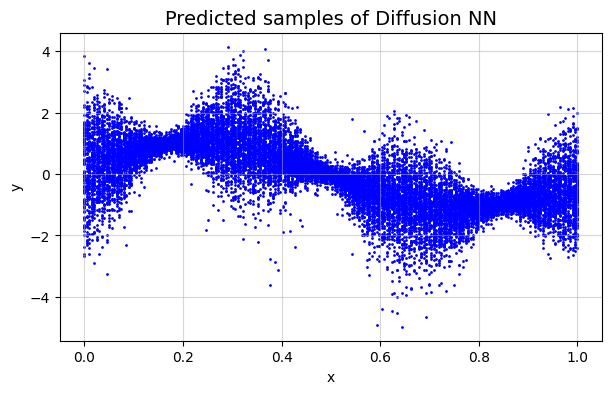

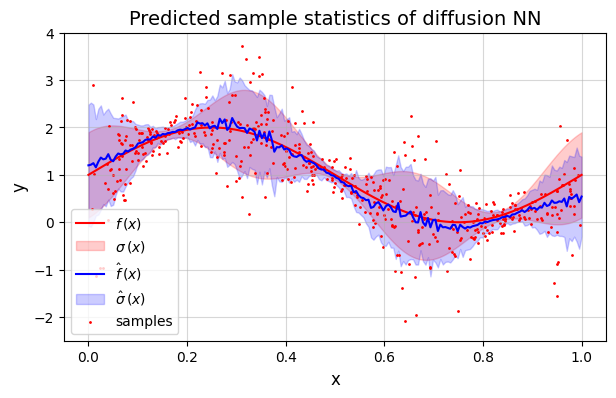

In [53]:
plot_param = {
    'figsize': (7, 4),
    'grid_alpha': 0.5,
    'xlabel_fontsize': 12,
    'ylabel_fontsize': 12,
    'legend_fontsize': 11,
    'title_fontsize': 14,
    'xticks_fontsize': 11,
    'yticks_fontsize': 11,
}
plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples of Diffusion NN', fontsize=plot_param['title_fontsize'])
for i in range(results.shape[0]):
    plt.scatter(locations[i]*torch.ones(num_samples), results[i], s=1, c='b', label='y_t')
# calculate the mean and std of the predicted samples
plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.title('Predicted sample statistics of diffusion NN', fontsize=plot_param['title_fontsize'])
y_pred_mean = np.mean(results, axis=1)
# get the variance of the predicted samples
y_pred_std = np.std(results, axis=1)
# plot the mean and std of the predicted samples
plt.plot(locations, f(locations), label=r'$f\,(x)$', c='r', linewidth=1.5)
plt.fill_between(locations, f(locations) - std(locations), f(locations) + std(locations), alpha=0.2, label=r'$\sigma\,(x)$', color='r')
y_pred_mean = y_scaler.inverse_transform(y_pred_mean.reshape(-1, 1))
plt.plot(locations, y_pred_mean, label=r'$\hat{f}\,(x)$', c='b', linewidth=1.5)
plt.fill_between(locations, y_pred_mean[:,0] - y_pred_std, y_pred_mean[:,0] + y_pred_std, alpha=0.2, label=r'$\hat{\sigma}\,(x)$', color='b')
# plot the true function
plt.scatter(test_locations, predictions, label='samples', c='r', s=1)
plt.ylim(-2.5, 4)
plt.legend()

In [11]:
# Arrange datasets suitable for GP models
train_dataset = dataset[train_loader.dataset.indices]
train_x = train_dataset['X'].flatten()
train_y = train_dataset['y'].flatten()
test_dataset = dataset[test_loader.dataset.indices]
test_x = test_dataset['X'].flatten()
test_y = test_dataset['y'].flatten()

# Sort indices
train_indices = np.argsort(train_x)
test_indices = np.argsort(test_x)

# Sort datasets
train_x = train_x[train_indices]
train_y = train_y[train_indices]
test_x = test_x[test_indices]
test_y = test_y[test_indices]

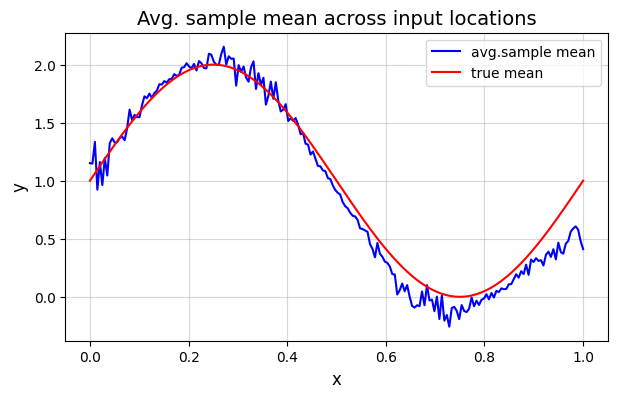

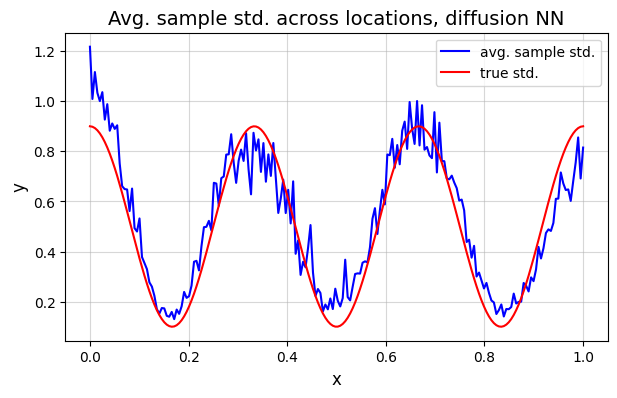

In [12]:
# plot the standard deviation across input locations
plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.title('Avg. sample mean across input locations', fontsize=plot_param['title_fontsize'])
plt.plot(locations, y_pred_mean, label='avg.sample mean', color='b')
# plot the true mean
plt.plot(locations, 1 + np.sin(2 * np.pi * locations), label='true mean', color='r')
plt.legend()

# plot the standard deviation across input locations
plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.title('Avg. sample std. across locations, diffusion NN', fontsize=plot_param['title_fontsize'])
plt.plot(locations, y_pred_std, label='avg. sample std.', color='b')
# plot the true standard deviation
plt.plot(locations, 0.5 + 0.4 * np.cos(6 * np.pi * locations), label='true std.', color='r')
# plt.ylim(-1, 1.5)
plt.legend()

# Graveyard

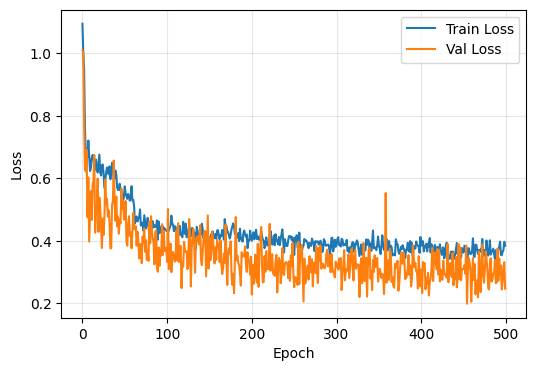

In [5]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.show()

In [7]:
num_locations = 200
x_locations = torch.linspace(0, 1, num_locations)
num_samples = 20
d = Diffusion(T=1000)
results = torch.zeros(num_locations,num_samples)

model.eval()
with torch.no_grad():
    with tqdm(range(len(x_locations))) as pbar:
        for i, location in enumerate(x_locations):
            x = torch.ones(num_samples) * location
            yt = torch.randn_like(x)
            for t in range(999,-1,-1):
                t_tensor = torch.ones(num_samples) * t
                score = model(x, yt, t_tensor)

                yt = (1/torch.sqrt(d.alphas[t])) * (yt - ((1-d.alphas[t+1])/torch.sqrt(1-d.alphas_cumprod[t+1])) * score)
                yt += torch.randn_like(yt) * torch.sqrt(d.betas[t+1])
            results[i] = yt
            pbar.update(1)

100%|██████████| 200/200 [00:20<00:00,  9.75it/s]


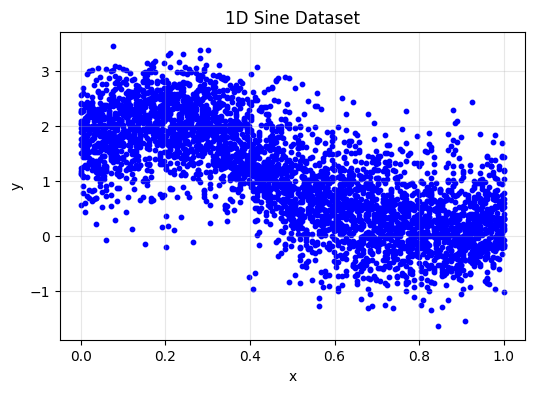

In [8]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
for i in range(results.shape[1]):
    plt.scatter(x_locations, results[:, i], s=10, c='b')
plt.show()


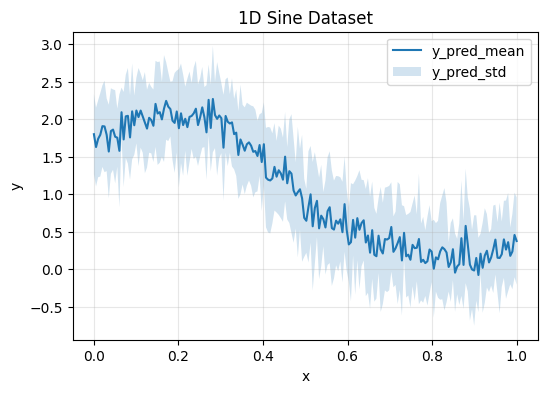

In [9]:
# calculate the mean of the y_pred
y_pred_mean = torch.mean(results, dim=1)
# calculate the std of the y_pred
y_pred_std = torch.std(results, dim=1)
# plot the y_pred
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Sine Dataset')
plt.plot(x_locations, y_pred_mean, label='y_pred_mean')
plt.fill_between(x_locations, y_pred_mean - y_pred_std, y_pred_mean + y_pred_std, alpha=0.2, label='y_pred_std')
plt.legend()
plt.show()